Actividad práctica 2: calculadora de calificaciones escolares con TensorFlow

Objetivo: Aplicar operaciones TensorFlow para simular un proceso educativo simple.

Alcance: Introducir tensores y operaciones básicas.

Producto final: Notebook funcional con cálculo de promedios usando TensorFlow.

In [1]:
# Paso 1: Importar TensorFlow
import tensorflow as tf

# Paso 2: Declarar tensores con calificaciones parciales (3 actividades por estudiante)
# Simularemos 5 estudiantes
calificaciones = tf.constant([
    [85.0, 90.0, 78.0],  # Estudiante 1
    [88.0, 92.0, 84.0],  # Estudiante 2
    [75.0, 70.0, 80.0],  # Estudiante 3
    [95.0, 94.0, 96.0],  # Estudiante 4
    [60.0, 65.0, 58.0],  # Estudiante 5
], dtype=tf.float32)
print("Calificaciones parciales (3 actividades por estudiante):")
print(calificaciones)

# Paso 3: Calcular el promedio simple por estudiante usando tf.reduce_mean
promedios = tf.reduce_mean(calificaciones, axis=1)
print("\nPromedio por estudiante:")
print(promedios)

# Paso 4: Calcular nota final ponderada
# Supongamos que: A1 = 30%, A2 = 30%, A3 = 40%
ponderaciones = tf.constant([0.3, 0.3, 0.4], dtype=tf.float32)
notas_finales = tf.reduce_sum(calificaciones * ponderaciones, axis=1)
print("\nNota final por estudiante (ponderada):")
print(notas_finales)

# Paso 5: Evaluar quién aprueba (nota final >= 70)
aprobados = notas_finales >= 70
print("\n¿Aprobado? (True = aprobado, False = reprobado):")
print(aprobados)

# Paso 6: Mostrar resultados finales por estudiante
nombres = ["Estudiante 1", "Estudiante 2", "Estudiante 3", "Estudiante 4", "Estudiante 5"]
for i in range(len(nombres)):
    estado = "Aprobado" if aprobados[i].numpy() else "Reprobado"
    print(f"{nombres[i]}: Nota Final = {notas_finales[i].numpy():.2f} --> {estado}")


Calificaciones parciales (3 actividades por estudiante):
tf.Tensor(
[[85. 90. 78.]
 [88. 92. 84.]
 [75. 70. 80.]
 [95. 94. 96.]
 [60. 65. 58.]], shape=(5, 3), dtype=float32)

Promedio por estudiante:
tf.Tensor([84.333336 88.       75.       95.       61.      ], shape=(5,), dtype=float32)

Nota final por estudiante (ponderada):
tf.Tensor([83.700005 87.600006 75.5      95.100006 60.7     ], shape=(5,), dtype=float32)

¿Aprobado? (True = aprobado, False = reprobado):
tf.Tensor([ True  True  True  True False], shape=(5,), dtype=bool)
Estudiante 1: Nota Final = 83.70 --> Aprobado
Estudiante 2: Nota Final = 87.60 --> Aprobado
Estudiante 3: Nota Final = 75.50 --> Aprobado
Estudiante 4: Nota Final = 95.10 --> Aprobado
Estudiante 5: Nota Final = 60.70 --> Reprobado


Actividad práctica 4: Implementación de regresión lineal con TensorFlow

Objetivo: Aplicar un modelo de regresión para predecir resultados escolares.

Alcance: Introducción al aprendizaje supervisado.

Instrucciones: Crear un dataset artificial: tareas entregadas vs. nota final. Implementar regresión lineal con TensorFlow. Visualizar la predicción y calcular el error.

Producto final: Notebook con modelo de regresión entrenado y validado.

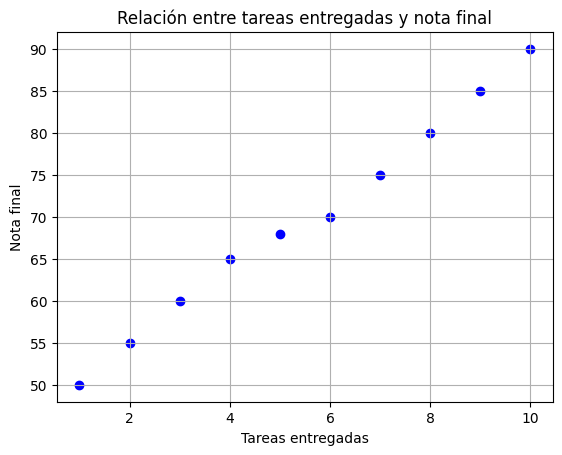

Epoch 0: pérdida = 5022.3999, W = 8.3800, b = 1.3960
Epoch 50: pérdida = 284.2001, W = 9.4540, b = 10.2025
Epoch 100: pérdida = 186.9286, W = 8.4674, b = 17.0711
Epoch 150: pérdida = 123.0703, W = 7.6680, b = 22.6364
Epoch 200: pérdida = 81.1475, W = 7.0202, b = 27.1457
Epoch 250: pérdida = 53.6252, W = 6.4954, b = 30.7993
Epoch 300: pérdida = 35.5570, W = 6.0702, b = 33.7596
Epoch 350: pérdida = 23.6953, W = 5.7257, b = 36.1582
Epoch 400: pérdida = 15.9081, W = 5.4465, b = 38.1016
Epoch 450: pérdida = 10.7959, W = 5.2203, b = 39.6763


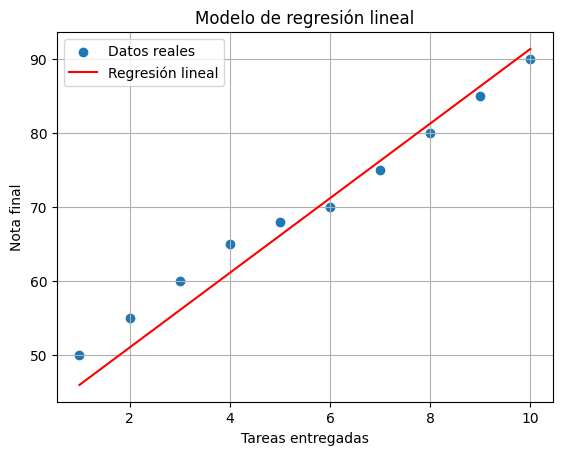

Predicción de nota para 7.0 tareas entregadas: 76.21
Error cuadrático medio final: 7.44


In [2]:
# Paso 1: Importar librerías necesarias
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Paso 2: Crear un dataset artificial (tareas entregadas vs nota final)
# Supongamos 10 estudiantes
tareas_entregadas = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], dtype=float)
nota_final = np.array([50, 55, 60, 65, 68, 70, 75, 80, 85, 90], dtype=float)

# Paso 3: Visualizar los datos
plt.scatter(tareas_entregadas, nota_final, color='blue')
plt.xlabel('Tareas entregadas')
plt.ylabel('Nota final')
plt.title('Relación entre tareas entregadas y nota final')
plt.grid(True)
plt.show()

# Paso 4: Normalizar los datos (opcional pero recomendable)
x = tareas_entregadas
y = nota_final

# Paso 5: Definir variables y modelo de regresión lineal
W = tf.Variable(0.0)
b = tf.Variable(0.0)

# Paso 6: Definir la función de predicción
def modelo_lineal(x):
    return W * x + b

# Paso 7: Definir la función de pérdida (MSE)
def loss(y_true, y_pred):
    return tf.reduce_mean(tf.square(y_true - y_pred))

# Paso 8: Optimizador
optimizador = tf.optimizers.SGD(learning_rate=0.01)

# Paso 9: Entrenamiento del modelo
for epoch in range(500):
    with tf.GradientTape() as tape:
        pred = modelo_lineal(x)
        current_loss = loss(y, pred)
    grad = tape.gradient(current_loss, [W, b])
    optimizador.apply_gradients(zip(grad, [W, b]))

    if epoch % 50 == 0:
        print(f"Epoch {epoch}: pérdida = {current_loss.numpy():.4f}, W = {W.numpy():.4f}, b = {b.numpy():.4f}")

# Paso 10: Visualizar la línea de regresión
plt.scatter(x, y, label='Datos reales')
plt.plot(x, modelo_lineal(x), color='red', label='Regresión lineal')
plt.xlabel('Tareas entregadas')
plt.ylabel('Nota final')
plt.title('Modelo de regresión lineal')
plt.legend()
plt.grid(True)
plt.show()

# Paso 11: Predicción de una nueva nota con 7 tareas entregadas
nueva_tarea = 7.0
prediccion = modelo_lineal(nueva_tarea)
print(f"Predicción de nota para {nueva_tarea} tareas entregadas: {prediccion.numpy():.2f}")

# Paso 12: Calcular error cuadrático medio final
error_final = loss(y, modelo_lineal(x))
print(f"Error cuadrático medio final: {error_final.numpy():.2f}")

Actividad práctica 5: “PrediNota” app para predecir calificaciones finales a partir de hábitos académicos

Objetivo: Diseñar una aplicación educativa interactiva que permita predecir la calificación final de un estudiante a partir de sus hábitos académicos usando un modelo de regresión con TensorFlow.

Alcance: Esta app puede ser utilizada por docentes o alumnos como herramienta de retroalimentación formativa, visualizando cómo variables como asistencia, tareas entregadas y participación afectan su rendimiento final.

In [3]:
# Paso 1: Importar bibliotecas necesarias
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, VBox, Output

# Paso 2: Crear dataset simulado
np.random.seed(42)
data = pd.DataFrame({
    'asistencia': np.random.randint(50, 101, 100),
    'tareas': np.random.randint(50, 101, 100),
    'participacion': np.random.randint(50, 101, 100)
})
data['nota_final'] = 0.3 * data['asistencia'] + 0.4 * data['tareas'] + 0.3 * data['participacion'] + np.random.normal(0, 5, 100)

# Paso 3: Normalización
X = data[['asistencia', 'tareas', 'participacion']].values / 100
y = data['nota_final'].values / 100

# Paso 4: Definir modelo
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu', input_shape=(3,)),
    tf.keras.layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.fit(X, y, epochs=100, verbose=0)

# Paso 5: Interfaz interactiva
out = Output()

def predecir(asistencia, tareas, participacion):
    entrada = np.array([[asistencia/100, tareas/100, participacion/100]])
    pred = model.predict(entrada)[0][0] * 100
    with out:
        out.clear_output()
        print(f"Predicción de nota final: {pred:.2f} / 100")

slider1 = FloatSlider(min=50, max=100, step=1, value=75, description='Asistencia')
slider2 = FloatSlider(min=50, max=100, step=1, value=75, description='Tareas')
slider3 = FloatSlider(min=50, max=100, step=1, value=75, description='Participación')

interact_ui = interact(predecir, asistencia=slider1, tareas=slider2, participacion=slider3)
VBox([interact_ui.widget, out])

c:\Users\L03555197\Dropbox\Mathematics\Teaching\Tec\Learning\Python Projects\TensorCollab\venv\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


interactive(children=(FloatSlider(value=75.0, description='Asistencia', min=50.0, step=1.0), FloatSlider(value…

Actividad práctica 7: “PlanTime” Estimador inteligente de tiempo necesario para estudiar

Objetivo: Crear una app educativa que estime el número de horas que un estudiante debe de estudiar para prepararse para un examen, tomando en cuenta la dificultad, el número de temas, su disponibilidad de tiempo y el nivel de dominio actual de los temas.

Alcance: Apoya la planificación del estudio personalizado, el cual es útil para las tutorías, autoevaluaciones y diseño de rutinas académicas.

Producto final: App interactiva implementada en Google Colab, que recibe parámetros del estudiante y devuelve una predicción razonable del tiempo necesario para estudiar.

In [4]:
# Paso 1: Importar bibliotecas necesarias
import tensorflow as tf
import numpy as np
import pandas as pd
from ipywidgets import interact, IntSlider, FloatSlider, VBox, Output
from IPython.display import display

# Paso 2: Dataset simulado
np.random.seed(123)
data = pd.DataFrame({
    'dificultad': np.random.randint(1, 6, 100),
    'temas': np.random.randint(5, 21, 100),
    'tiempo_disponible': np.random.randint(1, 6, 100),
    'dominio': np.random.rand(100)
})
data['horas_necesarias'] = (
    0.5 * data['dificultad'] +
    0.4 * data['temas'] -
    0.3 * data['tiempo_disponible'] -
    2.5 * data['dominio'] +
    np.random.normal(0, 1, 100)
)
data['horas_necesarias'] = data['horas_necesarias'].apply(lambda x: max(x, 1))

# Paso 3: Preparar datos
X = data[['dificultad', 'temas', 'tiempo_disponible', 'dominio']].values
y = data['horas_necesarias'].values

# Paso 4: Modelo de regresión
model = tf.keras.Sequential([
    tf.keras.layers.Dense(8, activation='relu', input_shape=(4,)),
    tf.keras.layers.Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X, y, epochs=100, verbose=0)


# Paso 5: Interfaz interactiva
out = Output()

def estimar(dificultad, temas, tiempo_disponible, dominio):
    entrada = np.array([[dificultad, temas, tiempo_disponible, dominio]])
    pred = model.predict(entrada)[0][0]
    with out:
        out.clear_output()
        print(f"Horas recomendadas de estudio: {pred:.2f} h")

slider_dificultad = IntSlider(min=1, max=5, value=3, description='Dificultad')
slider_temas = IntSlider(min=5, max=20, value=10, description='Temas')
slider_tiempo = IntSlider(min=1, max=5, value=3, description='Tiempo Disp.')
slider_dominio = FloatSlider(min=0, max=1, step=0.01, value=0.5, description='Dominio actual')

interact(estimar, dificultad=slider_dificultad, temas=slider_temas, tiempo_disponible=slider_tiempo, dominio=slider_dominio)
display(out)

c:\Users\L03555197\Dropbox\Mathematics\Teaching\Tec\Learning\Python Projects\TensorCollab\venv\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


interactive(children=(IntSlider(value=3, description='Dificultad', max=5, min=1), IntSlider(value=10, descript…

Output()